# Chapter 85 - Gradient Clipping

Gradient clipping is a safety mechanism for unusually large gradients.

This chapter measures total gradient norms, clips them between backpropagation and AdamW, and compares otherwise identical runs.

## Learning goals

By the end of this chapter, you will be able to:

- explain gradients, gradient norms, and exploding gradients;

- compute total gradient norm before and after clipping;

- use `torch.nn.utils.clip_grad_norm_` correctly;

- compare loss and gradient histories with and without clipping;

- measure how often a threshold actually activates; and

- explain why clipping raw gradients does not guarantee a bounded AdamW update or repair an unstable setup.

## Terms and the key correction

A **gradient** is the derivative of loss with respect to a parameter.

The **total gradient norm** combines all current parameter gradients into one magnitude.

**Exploding gradients** grow large enough to cause unstable optimization, loss spikes, overflow, or non-finite values.

**Norm clipping** rescales the complete gradient vector when its norm exceeds `max_norm`, preserving its direction up to floating-point effects.

Clipping bounds the raw gradient norm before AdamW, not the final parameter-update norm, because AdamW later applies adaptive scaling and weight decay.

## A scalar gradient

For `loss = weight ** 2`, the derivative is `2 * weight`.

In [1]:
import torch  # noqa: I001


weight = torch.tensor([10.0], requires_grad=True)
loss = weight.square().sum()
gradient = torch.autograd.grad(loss, weight)[0]

print("Loss:", float(loss.item()))
print("Gradient:", float(gradient.item()))
print("Gradient norm:", float(gradient.norm().item()))

assert float(gradient.item()) == 20.0

Loss: 100.0
Gradient: 20.0
Gradient norm: 20.0


## Clip a tiny parameter set

`clip_grad_norm_` modifies `.grad` tensors in place and returns the total norm from before clipping.

In [2]:
first_parameter = torch.nn.Parameter(torch.tensor([3.0]))
second_parameter = torch.nn.Parameter(torch.tensor([4.0]))
first_parameter.grad = torch.tensor([3.0])
second_parameter.grad = torch.tensor([4.0])

returned_pre_clip_norm = torch.nn.utils.clip_grad_norm_(
    [first_parameter, second_parameter],
    max_norm=1.0,
)
post_clip_norm = torch.sqrt(
    first_parameter.grad.square().sum() + second_parameter.grad.square().sum()
)

print("Returned pre-clip norm:", float(returned_pre_clip_norm.item()))
print("Post-clip norm:", float(post_clip_norm.item()))
print("Clipped gradients:", first_parameter.grad, second_parameter.grad)

assert torch.isclose(returned_pre_clip_norm, torch.tensor(5.0))
assert post_clip_norm <= 1.0 + 1e-6

Returned pre-clip norm: 5.0
Post-clip norm: 0.9999998211860657
Clipped gradients: tensor([0.6000]) tensor([0.8000])


The original vector `(3, 4)` has norm `5`, so clipping scales both components by approximately `1/5` rather than clamping them independently.

## Build a leakage-free character dataset

Three excerpts form training and a different excerpt forms validation.

In [3]:
training_documents = [
    """Alice was beginning to get very tired of sitting by her sister on the bank,
and of having nothing to do. Once or twice she had peeped into the book her
sister was reading, but it had no pictures or conversations in it, and what is
the use of a book, thought Alice, without pictures or conversation?""",
    """So she was considering in her own mind, as well as she could, for the hot day
made her feel very sleepy and stupid, whether the pleasure of making a daisy
chain would be worth the trouble of getting up and picking the daisies, when
suddenly a white rabbit with pink eyes ran close by her.""",
    """There was nothing so very remarkable in that; nor did Alice think it so very
much out of the way to hear the rabbit say to itself, Oh dear! Oh dear! I shall
be too late! But when the rabbit actually took a watch out of its waistcoat
pocket, and looked at it, and then hurried on, Alice started to her feet.""",
]
validation_text = """The rabbit hole went straight on like a tunnel for some way,
and then dipped suddenly down, so suddenly that Alice had not a moment to think
about stopping herself before she found herself falling down what seemed to be
a very deep well."""
training_text = "\n\n".join(training_documents)
characters = sorted(set(training_text))
character_to_id = {character: index for index, character in enumerate(characters)}


def encode_text(text: str) -> list[int]:
    unknown = sorted(set(text) - set(character_to_id))
    if unknown:
        raise ValueError(f"Unknown characters: {unknown!r}.")
    return [character_to_id[character] for character in text]


training_token_ids = torch.tensor(encode_text(training_text), dtype=torch.long)
validation_token_ids = torch.tensor(encode_text(validation_text), dtype=torch.long)
vocabulary_size = len(characters)

print("Vocabulary size:", vocabulary_size)
print("Training tokens:", training_token_ids.numel())
print("Validation tokens:", validation_token_ids.numel())

Vocabulary size: 35
Training tokens: 896
Validation tokens: 237


## Build identical batches

Explicit generators give both runs the same token windows.

In [4]:
def get_gpt_training_batch(
    token_ids: torch.Tensor,
    batch_size: int,
    context_length: int,
    generator: torch.Generator,
) -> tuple[torch.Tensor, torch.Tensor]:
    valid_starts = token_ids.numel() - context_length
    if token_ids.ndim != 1 or valid_starts < 1:
        raise ValueError(
            "Token stream must be one-dimensional and longer than context_length."
        )
    starts = torch.randint(0, valid_starts, (batch_size,), generator=generator)
    offsets = torch.arange(context_length)
    indexes = starts[:, None] + offsets[None, :]
    return token_ids[indexes], token_ids[indexes + 1]


test_generator = torch.Generator().manual_seed(85)
test_inputs, test_targets = get_gpt_training_batch(
    training_token_ids, 4, 16, test_generator
)
print("Input shape:", tuple(test_inputs.shape))
print("Target shift correct:", torch.equal(test_targets[:, :-1], test_inputs[:, 1:]))
assert torch.equal(test_targets[:, :-1], test_inputs[:, 1:])

Input shape: (4, 16)
Target shift correct: True


## Reuse TinyGPT

The dropout-aware architecture matches Chapters 83-84 so clipping is the only experimental change.

In [5]:
import math  # noqa: I001


class MultiHeadCausalSelfAttention(torch.nn.Module):
    embedding_dimension: int
    number_of_attention_heads: int
    head_size: int

    def __init__(
        self,
        embedding_dimension: int,
        number_of_attention_heads: int,
        context_length: int,
        dropout_rate: float,
    ) -> None:
        super().__init__()
        if embedding_dimension % number_of_attention_heads != 0:
            raise ValueError("Attention heads must divide the embedding dimension.")
        if not 0.0 <= dropout_rate < 1.0:
            raise ValueError("dropout_rate must be in [0, 1).")

        self.embedding_dimension = embedding_dimension
        self.number_of_attention_heads = number_of_attention_heads
        self.head_size = embedding_dimension // number_of_attention_heads
        self.query_projection = torch.nn.Linear(
            embedding_dimension,
            embedding_dimension,
            bias=False,
        )
        self.key_projection = torch.nn.Linear(
            embedding_dimension,
            embedding_dimension,
            bias=False,
        )
        self.value_projection = torch.nn.Linear(
            embedding_dimension,
            embedding_dimension,
            bias=False,
        )
        self.output_projection = torch.nn.Linear(
            embedding_dimension,
            embedding_dimension,
        )
        self.attention_dropout = torch.nn.Dropout(dropout_rate)
        self.output_dropout = torch.nn.Dropout(dropout_rate)
        self.register_buffer(
            "causal_mask",
            torch.tril(torch.ones(context_length, context_length, dtype=torch.bool)),
        )

    def forward(self, input_values: torch.Tensor) -> torch.Tensor:
        batch_size, sequence_length, _ = input_values.shape

        def split_heads(values: torch.Tensor) -> torch.Tensor:
            return values.view(
                batch_size,
                sequence_length,
                self.number_of_attention_heads,
                self.head_size,
            ).transpose(1, 2)

        queries = split_heads(self.query_projection(input_values))
        keys = split_heads(self.key_projection(input_values))
        values = split_heads(self.value_projection(input_values))
        attention_scores = queries @ keys.transpose(-2, -1)
        attention_scores = attention_scores / math.sqrt(self.head_size)
        causal_mask = self.causal_mask[:sequence_length, :sequence_length]
        attention_scores = attention_scores.masked_fill(
            ~causal_mask,
            float("-inf"),
        )
        attention_weights = torch.softmax(attention_scores, dim=-1)
        dropped_attention_weights = self.attention_dropout(attention_weights)
        attended_values = dropped_attention_weights @ values
        concatenated_values = (
            attended_values.transpose(1, 2)
            .contiguous()
            .view(
                batch_size,
                sequence_length,
                self.embedding_dimension,
            )
        )
        projected_values = self.output_projection(concatenated_values)
        output_values: torch.Tensor = self.output_dropout(projected_values)
        return output_values

In [6]:
class FeedForwardNetwork(torch.nn.Module):
    def __init__(self, embedding_dimension: int, dropout_rate: float) -> None:
        super().__init__()
        self.network = torch.nn.Sequential(
            torch.nn.Linear(embedding_dimension, 4 * embedding_dimension),
            torch.nn.ReLU(),
            torch.nn.Linear(4 * embedding_dimension, embedding_dimension),
            torch.nn.Dropout(dropout_rate),
        )

    def forward(self, input_values: torch.Tensor) -> torch.Tensor:
        output_values: torch.Tensor = self.network(input_values)
        return output_values


class TransformerBlock(torch.nn.Module):
    def __init__(
        self,
        embedding_dimension: int,
        number_of_attention_heads: int,
        context_length: int,
        dropout_rate: float,
    ) -> None:
        super().__init__()
        self.attention_norm = torch.nn.LayerNorm(embedding_dimension)
        self.attention = MultiHeadCausalSelfAttention(
            embedding_dimension=embedding_dimension,
            number_of_attention_heads=number_of_attention_heads,
            context_length=context_length,
            dropout_rate=dropout_rate,
        )
        self.feedforward_norm = torch.nn.LayerNorm(embedding_dimension)
        self.feedforward = FeedForwardNetwork(
            embedding_dimension=embedding_dimension,
            dropout_rate=dropout_rate,
        )

    def forward(self, input_values: torch.Tensor) -> torch.Tensor:
        attention_branch = self.attention(self.attention_norm(input_values))
        values_after_attention = input_values + attention_branch
        feedforward_branch = self.feedforward(
            self.feedforward_norm(values_after_attention)
        )
        output_values: torch.Tensor = values_after_attention + feedforward_branch
        return output_values

In [7]:
class TinyGPT(torch.nn.Module):
    vocabulary_size: int
    context_length: int
    dropout_rate: float

    def __init__(
        self,
        vocabulary_size: int,
        context_length: int,
        embedding_dimension: int,
        number_of_attention_heads: int,
        number_of_transformer_blocks: int,
        dropout_rate: float,
    ) -> None:
        super().__init__()
        if not 0.0 <= dropout_rate < 1.0:
            raise ValueError("dropout_rate must be in [0, 1).")
        self.vocabulary_size = vocabulary_size
        self.context_length = context_length
        self.dropout_rate = dropout_rate
        self.token_embedding = torch.nn.Embedding(
            vocabulary_size,
            embedding_dimension,
        )
        self.position_embedding = torch.nn.Embedding(
            context_length,
            embedding_dimension,
        )
        self.embedding_dropout = torch.nn.Dropout(dropout_rate)
        self.transformer_blocks = torch.nn.ModuleList(
            [
                TransformerBlock(
                    embedding_dimension=embedding_dimension,
                    number_of_attention_heads=number_of_attention_heads,
                    context_length=context_length,
                    dropout_rate=dropout_rate,
                )
                for _ in range(number_of_transformer_blocks)
            ]
        )
        self.final_norm = torch.nn.LayerNorm(embedding_dimension)
        self.output_layer = torch.nn.Linear(embedding_dimension, vocabulary_size)

    def forward(
        self,
        input_token_ids: torch.Tensor,
        target_token_ids: torch.Tensor | None = None,
    ) -> tuple[torch.Tensor, torch.Tensor | None]:
        if input_token_ids.ndim != 2:
            raise ValueError("Inputs must have shape [batch, time].")
        batch_size, sequence_length = input_token_ids.shape
        if sequence_length > self.context_length:
            raise ValueError("Input exceeds model context length.")

        position_ids = torch.arange(sequence_length, device=input_token_ids.device)
        hidden_values = self.token_embedding(input_token_ids)
        hidden_values = hidden_values + self.position_embedding(position_ids)
        hidden_values = self.embedding_dropout(hidden_values)
        for transformer_block in self.transformer_blocks:
            hidden_values = transformer_block(hidden_values)
        logits = self.output_layer(self.final_norm(hidden_values))

        loss = None
        if target_token_ids is not None:
            if target_token_ids.shape != input_token_ids.shape:
                raise ValueError("Targets must have the same shape as inputs.")
            loss = torch.nn.functional.cross_entropy(
                logits.reshape(batch_size * sequence_length, self.vocabulary_size),
                target_token_ids.reshape(batch_size * sequence_length),
            )
        return logits, loss

    @torch.no_grad()
    def generate(
        self,
        input_token_ids: torch.Tensor,
        number_of_new_tokens: int,
        generator: torch.Generator,
        temperature: float = 1.0,
        top_k: int | None = None,
    ) -> torch.Tensor:
        if temperature <= 0:
            raise ValueError("temperature must be positive.")
        generated_ids = input_token_ids
        for _ in range(number_of_new_tokens):
            model_input = generated_ids[:, -self.context_length :]
            logits, _ = self(model_input)
            next_logits = logits[:, -1, :] / temperature
            if top_k is not None:
                effective_top_k = min(top_k, self.vocabulary_size)
                top_values, _ = torch.topk(next_logits, effective_top_k)
                next_logits = next_logits.masked_fill(
                    next_logits < top_values[:, -1, None],
                    float("-inf"),
                )
            probabilities = torch.softmax(next_logits, dim=-1)
            next_ids = torch.multinomial(
                probabilities,
                num_samples=1,
                generator=generator,
            )
            generated_ids = torch.cat([generated_ids, next_ids], dim=1)
        return generated_ids

## Configure the controlled comparison

The learning rate `0.001` is higher than recent chapters but still must be diagnosed from measured gradients rather than declared unstable in advance.

In [8]:
from typing import TypedDict


class ClippingConfig(TypedDict):
    context_length: int
    embedding_dimension: int
    number_of_attention_heads: int
    number_of_transformer_blocks: int
    dropout_rate: float
    batch_size: int
    learning_rate: float
    weight_decay: float
    training_steps: int
    evaluation_interval: int
    evaluation_batches: int
    max_gradient_norm: float


clipping_config: ClippingConfig = {
    "context_length": 64,
    "embedding_dimension": 64,
    "number_of_attention_heads": 4,
    "number_of_transformer_blocks": 2,
    "dropout_rate": 0.1,
    "batch_size": 8,
    "learning_rate": 0.001,
    "weight_decay": 0.01,
    "training_steps": 800,
    "evaluation_interval": 100,
    "evaluation_batches": 8,
    "max_gradient_norm": 1.0,
}
print(clipping_config)

{'context_length': 64, 'embedding_dimension': 64, 'number_of_attention_heads': 4, 'number_of_transformer_blocks': 2, 'dropout_rate': 0.1, 'batch_size': 8, 'learning_rate': 0.001, 'weight_decay': 0.01, 'training_steps': 800, 'evaluation_interval': 100, 'evaluation_batches': 8, 'max_gradient_norm': 1.0}


## Compute and validate gradient norms

The helper matches the default L2 norm used by `clip_grad_norm_` and rejects non-finite gradients before clipping.

In [9]:
def compute_total_gradient_norm(model: torch.nn.Module) -> float:
    squared_sum = sum(
        float(parameter.grad.detach().square().sum().item())
        for parameter in model.parameters()
        if parameter.grad is not None
    )
    return math.sqrt(squared_sum)


def check_gradients_are_finite(model: torch.nn.Module) -> None:
    for parameter_name, parameter in model.named_parameters():
        if parameter.grad is not None and not torch.isfinite(parameter.grad).all():
            raise RuntimeError(f"Non-finite gradient in {parameter_name}.")

## Evaluate fixed batches with dropout off

Checkpoint losses reuse the same train and validation batches across runs.

In [10]:
@torch.no_grad()
def estimate_losses(
    model: TinyGPT, config: ClippingConfig, seed: int
) -> dict[str, float]:
    was_training = model.training
    model.eval()
    results: dict[str, float] = {}
    for offset, (name, token_ids) in enumerate(
        [("train", training_token_ids), ("validation", validation_token_ids)]
    ):
        generator = torch.Generator().manual_seed(seed + offset)
        losses: list[float] = []
        for _ in range(config["evaluation_batches"]):
            inputs, targets = get_gpt_training_batch(
                token_ids, config["batch_size"], config["context_length"], generator
            )
            _, loss = model(inputs, targets)
            if loss is None or not torch.isfinite(loss):
                raise RuntimeError("Evaluation loss is non-finite.")
            losses.append(float(loss.item()))
        results[name] = sum(losses) / len(losses)
    model.train(was_training)
    return results

## Train with optional clipping

Every norm is recorded before clipping, and the clipped run also records the norm after in-place rescaling.

The loop performs exactly 800 updates.

In [11]:
from dataclasses import dataclass


@dataclass
class ClippingResult:
    model: TinyGPT
    clipping_enabled: bool
    evaluation_steps: list[int]
    training_losses: list[float]
    validation_losses: list[float]
    update_steps: list[int]
    pre_clip_norms: list[float]
    post_clip_norms: list[float]
    clipped_update_count: int
    optimizer_updates: int


def train_with_optional_clipping(
    clipping_enabled: bool,
    config: ClippingConfig,
) -> ClippingResult:
    torch.manual_seed(8501)
    model = TinyGPT(
        vocabulary_size=vocabulary_size,
        context_length=config["context_length"],
        embedding_dimension=config["embedding_dimension"],
        number_of_attention_heads=config["number_of_attention_heads"],
        number_of_transformer_blocks=config["number_of_transformer_blocks"],
        dropout_rate=config["dropout_rate"],
    )
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=config["learning_rate"],
        weight_decay=config["weight_decay"],
    )
    batch_generator = torch.Generator().manual_seed(8502)
    evaluation_steps: list[int] = []
    training_losses: list[float] = []
    validation_losses: list[float] = []
    update_steps: list[int] = []
    pre_clip_norms: list[float] = []
    post_clip_norms: list[float] = []
    clipped_update_count = 0

    def checkpoint(step: int) -> None:
        losses = estimate_losses(model, config, seed=8503)
        evaluation_steps.append(step)
        training_losses.append(losses["train"])
        validation_losses.append(losses["validation"])
        print(
            f"clipping={clipping_enabled} | step {step:>3} | "
            f"train {losses['train']:.4f} | validation {losses['validation']:.4f}"
        )

    torch.manual_seed(8502)
    model.train()
    checkpoint(0)
    for step in range(1, config["training_steps"] + 1):
        inputs, targets = get_gpt_training_batch(
            training_token_ids,
            config["batch_size"],
            config["context_length"],
            batch_generator,
        )
        logits, loss = model(inputs, targets)
        if loss is None or not torch.isfinite(loss):
            raise RuntimeError("Training loss is non-finite.")
        if logits.shape[-1] != vocabulary_size:
            raise RuntimeError("Incorrect logit dimension.")
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        check_gradients_are_finite(model)
        pre_clip_norm = compute_total_gradient_norm(model)
        post_clip_norm = pre_clip_norm
        if clipping_enabled:
            returned_norm = torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=config["max_gradient_norm"],
                error_if_nonfinite=True,
            )
            if not math.isclose(
                float(returned_norm.item()), pre_clip_norm, rel_tol=1e-5
            ):
                raise RuntimeError(
                    "Returned norm disagrees with measured pre-clip norm."
                )
            post_clip_norm = compute_total_gradient_norm(model)
            if pre_clip_norm > config["max_gradient_norm"]:
                clipped_update_count += 1
        update_steps.append(step)
        pre_clip_norms.append(pre_clip_norm)
        post_clip_norms.append(post_clip_norm)
        optimizer.step()
        if step % config["evaluation_interval"] == 0:
            checkpoint(step)

    return ClippingResult(
        model,
        clipping_enabled,
        evaluation_steps,
        training_losses,
        validation_losses,
        update_steps,
        pre_clip_norms,
        post_clip_norms,
        clipped_update_count,
        config["training_steps"],
    )

## Run both experiments

Identical seeds align initialization, batches, and dropout masks until clipping changes the parameter trajectory.

In [12]:
without_clipping = train_with_optional_clipping(False, clipping_config)
with_clipping = train_with_optional_clipping(True, clipping_config)

print(
    "Clipped updates:",
    with_clipping.clipped_update_count,
    "of",
    with_clipping.optimizer_updates,
)
print("Maximum pre-clip norm:", max(with_clipping.pre_clip_norms))
print("Maximum post-clip norm:", max(with_clipping.post_clip_norms))

clipping=False | step   0 | train 3.7232 | validation 3.7209


clipping=False | step 100 | train 2.2806 | validation 2.6380


clipping=False | step 200 | train 2.0799 | validation 2.6256


clipping=False | step 300 | train 1.9531 | validation 2.6650


clipping=False | step 400 | train 1.7908 | validation 2.7062


...

clipping=True | step 400 | train 1.7908 | validation 2.7062


clipping=True | step 500 | train 1.6178 | validation 2.7764


clipping=True | step 600 | train 1.4386 | validation 2.9293


clipping=True | step 700 | train 1.2321 | validation 2.9531


clipping=True | step 800 | train 1.0658 | validation 3.1137
Clipped updates: 12 of 800
Maximum pre-clip norm: 1.0810730296642608
Maximum post-clip norm: 0.9999991651708268


## Plot gradients and losses

The first panel compares raw norms, the second shows clipping's direct effect, and the third compares deterministic checkpoint losses.

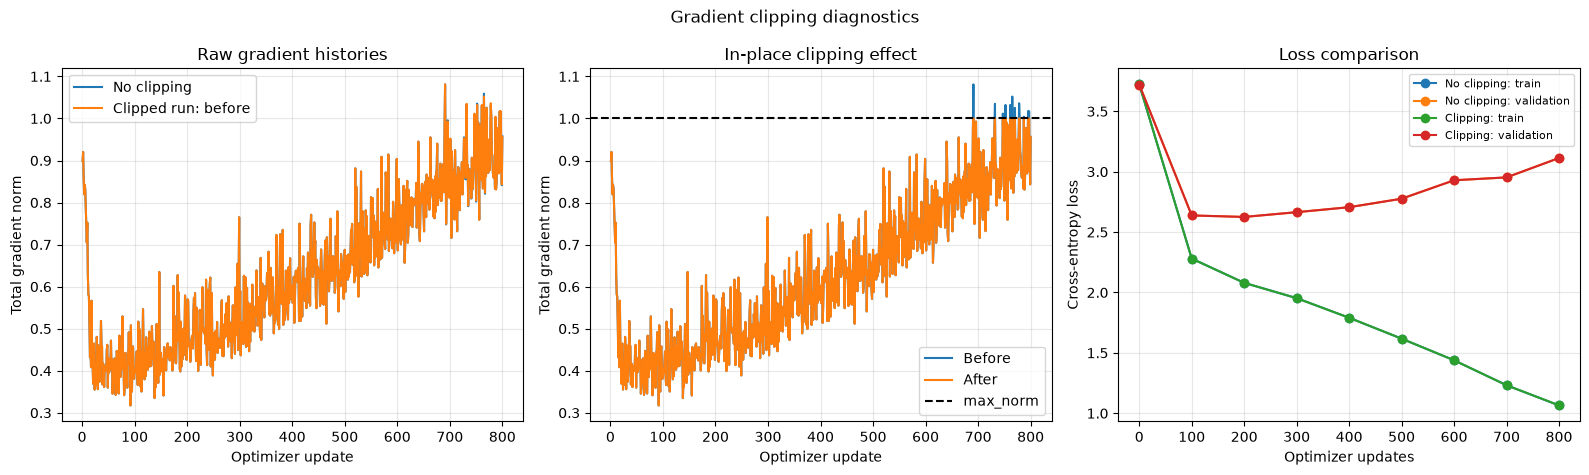

In [13]:
import matplotlib.pyplot as plt  # noqa: I001


figure, axes = plt.subplots(1, 3, figsize=(16, 4.8))
axes[0].plot(
    without_clipping.update_steps, without_clipping.pre_clip_norms, label="No clipping"
)
axes[0].plot(
    with_clipping.update_steps,
    with_clipping.pre_clip_norms,
    label="Clipped run: before",
)
axes[0].set_xlabel("Optimizer update")
axes[0].set_ylabel("Total gradient norm")
axes[0].set_title("Raw gradient histories")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(with_clipping.update_steps, with_clipping.pre_clip_norms, label="Before")
axes[1].plot(with_clipping.update_steps, with_clipping.post_clip_norms, label="After")
axes[1].axhline(
    clipping_config["max_gradient_norm"],
    linestyle="--",
    color="black",
    label="max_norm",
)
axes[1].set_xlabel("Optimizer update")
axes[1].set_ylabel("Total gradient norm")
axes[1].set_title("In-place clipping effect")
axes[1].legend()
axes[1].grid(alpha=0.3)

for result, prefix in [(without_clipping, "No clipping"), (with_clipping, "Clipping")]:
    axes[2].plot(
        result.evaluation_steps,
        result.training_losses,
        marker="o",
        label=f"{prefix}: train",
    )
    axes[2].plot(
        result.evaluation_steps,
        result.validation_losses,
        marker="o",
        label=f"{prefix}: validation",
    )
axes[2].set_xlabel("Optimizer updates")
axes[2].set_ylabel("Cross-entropy loss")
axes[2].set_title("Loss comparison")
axes[2].legend(fontsize=8)
axes[2].grid(alpha=0.3)

figure.suptitle("Gradient clipping diagnostics")
figure.tight_layout()
plt.show()

## Interpret activation frequency

Clipping that rarely activates is a safety rail and should produce a trajectory close to the unclipped run.

Clipping on nearly every update means the threshold materially changes optimization and should trigger investigation of the learning rate, architecture, initialization, loss, masks, and data.

In [14]:
activation_fraction = (
    with_clipping.clipped_update_count / with_clipping.optimizer_updates
)
print("Clipping activation fraction:", f"{activation_fraction:.1%}")
print("Final validation without clipping:", without_clipping.validation_losses[-1])
print("Final validation with clipping:", with_clipping.validation_losses[-1])

Clipping activation fraction: 1.5%
Final validation without clipping: 3.1134088039398193
Final validation with clipping: 3.1136609315872192


The measured loss curves decide whether clipping helped this run; clipping is not automatically beneficial when gradients are already well behaved.

Here clipping activates on only 12 of 800 updates, and the largest raw norm is only about `1.081`, so the loss trajectories are nearly identical.

Both validation curves worsen after their early minimum while training loss continues falling, which diagnoses overfitting rather than exploding gradients.

Clipping does not address that failure mode.

## Correct operation order

The required order is `zero_grad`, forward loss, `backward`, finite-gradient check, optional clipping, and then `optimizer.step`.

Clipping before `backward` acts on missing or stale gradients, while clipping after `optimizer.step` is too late for that update.

## Verify the contracts

The post-clipping norm may exceed the threshold only by a tiny floating-point tolerance.

In [15]:
expected_steps = list(range(0, 801, 100))
assert without_clipping.optimizer_updates == 800
assert with_clipping.optimizer_updates == 800
assert without_clipping.evaluation_steps == expected_steps
assert with_clipping.evaluation_steps == expected_steps
assert max(with_clipping.post_clip_norms) <= clipping_config["max_gradient_norm"] + 1e-5
assert all(math.isfinite(value) for value in without_clipping.pre_clip_norms)
assert all(math.isfinite(value) for value in with_clipping.pre_clip_norms)
assert all(math.isfinite(value) for value in with_clipping.validation_losses)

print("Exact 800-update runs: passed")
print("Finite gradient histories: passed")
print("Post-clipping threshold: passed")
print("Deterministic checkpoint schedule: passed")

Exact 800-update runs: passed
Finite gradient histories: passed
Post-clipping threshold: passed
Deterministic checkpoint schedule: passed


## Common mistakes

- Saying clipping bounds the AdamW update confuses raw gradients with adaptively transformed updates.

- Clipping before backpropagation or after the optimizer step places the operation at the wrong time.

- Reading `clip_grad_norm_`'s return value as the post-clipping norm reverses its meaning.

- Sampling different batches for each run makes gradient comparisons needlessly noisy.

- Allowing non-finite gradients into clipping can hide the location of the original numerical failure.

- Constant clipping can conceal an excessive learning rate, broken masking, bad normalization, or another root cause.

- Taking an update after the final checkpoint creates an off-by-one experiment.

## Takeaways

- Gradients describe how loss changes with parameters.

- `clip_grad_norm_` rescales the combined raw gradient vector in place when its norm exceeds `max_norm`.

- The function returns the norm from before clipping.

- Clipping belongs after `loss.backward()` and before `optimizer.step()`.

- Tracking pre-clip norm, post-clip norm, and activation frequency shows whether clipping is doing anything.

- A controlled comparison needs identical initialization, batches, dropout randomness, held-out data, and update counts.

- Clipping is a safety tool, not a substitute for diagnosing persistent gradient instability.

## What comes next

Gradient clipping limits exceptional raw gradients, while learning-rate schedules control the planned update scale across training.

The next optimization tools should preserve the same measurement and held-out evaluation discipline.